In [1]:
import pandas as pd
import numpy as np
# it help to check that how much my data is normally distributed using qq plot
import scipy.stats as stats
# imputer
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv("train.csv", usecols=["Age", "Fare", "Survived"])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [5]:
imputer = SimpleImputer(strategy="mean")

imputer.fit(df[["Age", "Fare"]])
df[["Age", "Fare"]] = imputer.transform(df[["Age", "Fare"]])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
# X = df[["Age", "Fare"]]
# y = df["Survived"]

X = df.iloc[:, 1:3]
y = df.iloc[:, 0]



In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

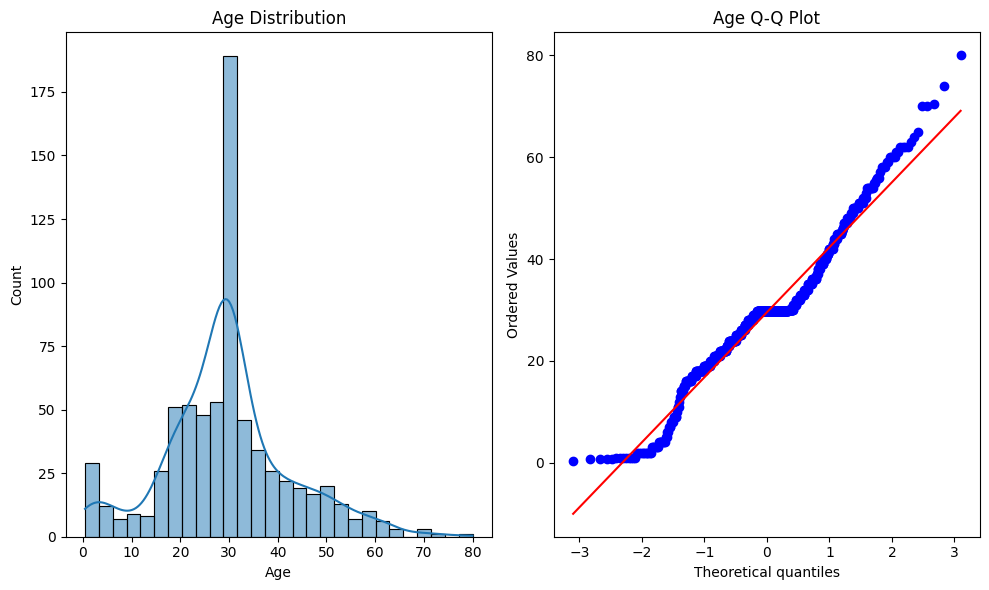

In [11]:
plt.figure(figsize=(10, 6))

# First plot
plt.subplot(1, 2, 1)
sns.histplot(X_train["Age"], kde=True)
plt.title("Age Distribution")

# Second plot (Q-Q plot)
plt.subplot(1, 2, 2)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age Q-Q Plot")

plt.tight_layout()
plt.show()

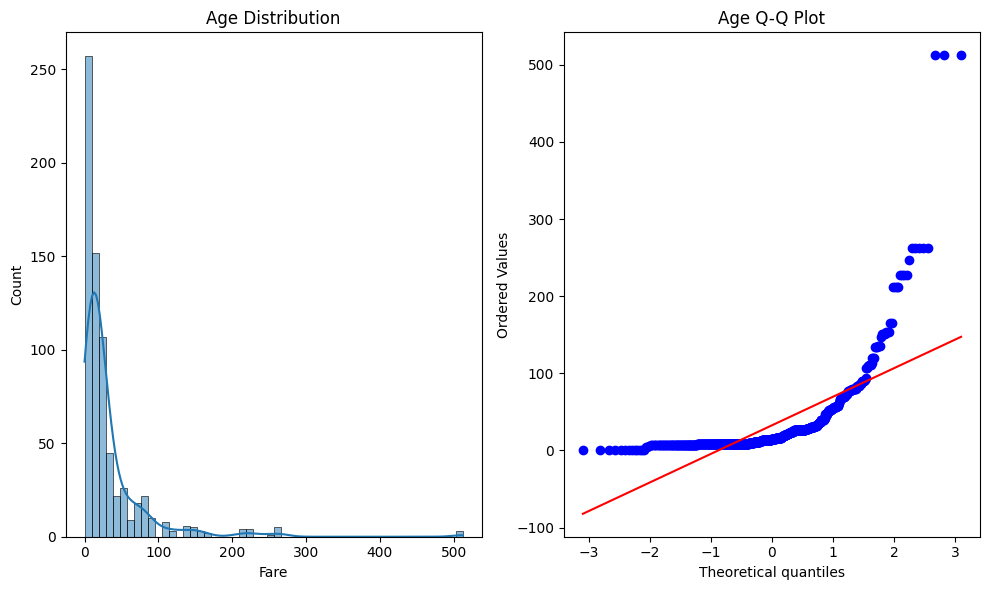

In [12]:
plt.figure(figsize=(10, 6))

# First plot
plt.subplot(1, 2, 1)
sns.histplot(X_train["Fare"], kde=True)
plt.title("Age Distribution")

# Second plot (Q-Q plot)
plt.subplot(1, 2, 2)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Age Q-Q Plot")

plt.tight_layout()
plt.show()

In [13]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [14]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.6536312849162011


Applying Transformer

In [15]:
trf = FunctionTransformer(np.log1p, validate=True)
col_trf = ColumnTransformer(
    transformers=[("log", trf, ["Age", "Fare"])], remainder="passthrough"
)

In [16]:
pipe1 = Pipeline(
    steps=[
        ("transformer", col_trf),
        ("classifier", clf),
    ]
)

pipe1.fit(X_train, y_train)
y_pred_pipeline = pipe1.predict(X_test)
print("Pipeline Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_pipeline))


pipe2 = Pipeline(
    steps=[
        ("transformer", col_trf),
        ("classifier", clf2),
    ]
)

pipe2.fit(X_train, y_train)
y_pred_pipeline2 = pipe2.predict(X_test)
print("Pipeline Decision Tree Accuracy:", accuracy_score(y_test, y_pred_pipeline2))

Pipeline Logistic Regression Accuracy: 0.6815642458100558
Pipeline Decision Tree Accuracy: 0.6703910614525139
